In [ ]:
#!git clone -b bao-update https://github.com/Briannguyen3106/flood-forecast.git
#%cd flood-forecast
#!pip install -r requirements.txt

Cloning into 'flood-forecast'...
remote: Enumerating objects: 306, done.
remote: Counting objects: 100% (306/306), done.
remote: Compressing objects: 100% (244/244), done.
remote: Total 306 (delta 125), reused 125 (delta 56), pack-reused 0 (from 0)
Receiving objects: 100% (306/306), 23.93 MiB | 22.61 MiB/s, done.
Resolving deltas: 100% (125/125), done.
/kaggle/working/flood-forecast


In [2]:
# experiments/2_final_training.ipynb

# ================================================================== #
# CELL 1 — Setup
# ================================================================== #
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import json
from pathlib import Path
from sklearn.metrics import (
    fbeta_score, f1_score,
    classification_report, confusion_matrix
)

# Core
from src.core.trainer import Trainer
from src.core.evaluator import Evaluator

# Tree models
from src.model.decision_tree_classifier import DecisionTreeClassifierModel
from src.model.random_forest_classifier import RandomForestClassifierModel
from src.model.xgb_classifier           import XGBClassifierModel
from src.model.xgbrf_classifier         import XGBRFClassifierModel
from src.model.lgbm_scratch_v2             import LGBMScratchModel
from src.model.hist_gradient_boosting_classifier import HistGradientBoostingClassifierModel

# Linear/Distance models
from src.model.linear_regression import LinearRegressionModel
from src.model.ridge_regression  import RidgeRegressionModel
from src.model.lasso_regression  import LassoRegressionModel
from src.model.huber_regression  import HuberRegressionModel
from src.model.svm_classifier    import SVMClassifierModel

RANDOM_STATE = 42
N_ITER       = 100
RESULTS_DIR  = Path('../flood-forecast/results/final')
MODELS_DIR   = Path('../flood-forecast/saved_models')
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print("Setup done!")

Setup done!


In [3]:
# ================================================================== #
# CELL 2 — Load Data
# ================================================================== #

# Train sets (processed) — dùng để tune
train_tree   = pd.read_csv('../flood-forecast/data/processed/tree/train.csv')
train_linear = pd.read_csv('../flood-forecast/data/processed/linear/train.csv')

# Test sets (processed) — chỉ dùng 1 lần cuối cùng
test_tree    = pd.read_csv('../flood-forecast/data/processed/tree/test.csv')
test_linear  = pd.read_csv('../flood-forecast/data/processed/linear/test.csv')

print(f"train_tree   : {train_tree.shape}")
print(f"train_linear : {train_linear.shape}")
print(f"test_tree    : {test_tree.shape}")
print(f"test_linear  : {test_linear.shape}")

print(f"\nClass distribution (train_tree):")
print(train_tree['risk_class'].value_counts())

train_tree   : (2370, 18)
train_linear : (2370, 38)
test_tree    : (593, 18)
test_linear  : (593, 38)

Class distribution (train_tree):
risk_class
Low       1595
Medium     459
High       316
Name: count, dtype: int64


In [4]:
# ================================================================== #
# CELL 3 — Helper Functions
# ================================================================== #
 
def get_X_y(df: pd.DataFrame):
    """Tách features và target từ DataFrame đã preprocess"""
    drop_cols    = ['risk_class', 'risk_class_encoded',
                    'latitude', 'longitude']
    feature_cols = [c for c in df.columns if c not in drop_cols]
    X = df[feature_cols].values
    y = df['risk_class_encoded'].values
    return X, y, feature_cols
 
 
def train_and_save(model, train_df, test_df, model_name, n_iter=100):
    """
    Train model → evaluate train/test → lưu pkl.
    Trả về (trainer, metrics_by_split).
    """
    trainer = Trainer(
        model        = model,
        n_iter       = n_iter,
        random_state = RANDOM_STATE,
        cv           = 10
    )
    trainer.tune(train_df)
    train_metrics = trainer.evaluate_train(train_df)
    test_metrics  = trainer.evaluate_test(test_df)
 
    # Lưu pkl
    pkl_path = MODELS_DIR / f"{model_name}.pkl"
    with open(pkl_path, 'wb') as f:
        pickle.dump(trainer.pipeline, f)
    print(f"  Saved: {pkl_path}")
 
    return trainer, {
        'train_f2_macro'   : train_metrics['f2_macro'],
        'train_f1_weighted': train_metrics['f1_weighted'],
        'test_f2_macro'    : test_metrics['f2_macro'],
        'test_f1_weighted' : test_metrics['f1_weighted'],
    }
 
 
def load_pkl(model_name) -> object:
    """Load pipeline từ pkl"""
    pkl_path = MODELS_DIR / f"{model_name}.pkl"
    with open(pkl_path, 'rb') as f:
        pipeline = pickle.load(f)
    print(f"  Loaded: {pkl_path}")
    return pipeline
 
 
def evaluate_split(pipeline, df: pd.DataFrame) -> dict:
    """Evaluate a loaded or newly trained pipeline on one split."""
    X, y, _ = get_X_y(df)
    y_pred = pipeline.predict(X)
    return {
        'f2_macro': fbeta_score(
            y, y_pred, beta=2, average='macro', zero_division=0
        ),
        'f1_weighted': f1_score(
            y, y_pred, average='weighted', zero_division=0
        ),
    }
 
 
def compute_metrics(model_name, test_df,
                    pipeline=None, trainer=None) -> dict:
    """
    Tính F2-macro, F1-weighted, per-class, confusion matrix.
    Nhận pipeline (từ pkl) hoặc trainer (vừa train xong).
    """
    if pipeline is None and trainer is not None:
        pipeline = trainer.pipeline
    elif pipeline is None:
        pipeline = load_pkl(model_name)
 
    X_test, y_test, _ = get_X_y(test_df)
    y_pred = pipeline.predict(X_test)
 
    label_names = ['High', 'Low', 'Medium']
    report      = classification_report(
        y_test, y_pred,
        target_names=label_names,
        output_dict=True
    )
    cm = confusion_matrix(y_test, y_pred)
 
    return {
        'model'           : model_name,
        'f2_macro'        : fbeta_score(
            y_test, y_pred, beta=2, average='macro', zero_division=0
        ),
        'f1_weighted'     : f1_score(
            y_test, y_pred, average='weighted', zero_division=0
        ),
        'per_class'       : report,
        'confusion_matrix': cm.tolist(),
        'best_params'     : getattr(
            pipeline.named_steps.get('model'), 'best_params', None
        ),
    }
 
 
print("Helper functions ready!")

Helper functions ready!


In [5]:
# ================================================================== #
# CELL 4 — Định nghĩa tất cả models
# ================================================================== #
 
# (model_class, train_df, test_df, n_iter)
ALL_MODEL_CONFIGS = {
    # ── Tree models ────────────────────────────────────────────────
    'DecisionTree': (DecisionTreeClassifierModel, train_tree,   test_tree,   N_ITER),
    'RandomForest': (RandomForestClassifierModel, train_tree,   test_tree,   N_ITER),
    'XGBoost'     : (XGBClassifierModel,          train_tree,   test_tree,   N_ITER),
    'XGBRF'       : (XGBRFClassifierModel,         train_tree,   test_tree,   N_ITER),
    'LightGBM'    : (LGBMScratchModel,          train_tree,   test_tree,   N_ITER),
    'HitsGB'      : (HistGradientBoostingClassifierModel, train_tree, test_tree, N_ITER),
 
    # ── Linear/Distance models ─────────────────────────────────────
    'LinearRegression': (LinearRegressionModel, train_linear, test_linear, N_ITER),
    'Ridge'           : (RidgeRegressionModel,  train_linear, test_linear, N_ITER),
    'Lasso'           : (LassoRegressionModel,  train_linear, test_linear, N_ITER),
    'Huber'           : (HuberRegressionModel,  train_linear, test_linear, N_ITER),
    'SVM'             : (SVMClassifierModel,    train_linear, test_linear, N_ITER),
}
 
TREE_MODELS   = ['DecisionTree', 'RandomForest', 'XGBoost',
                  'XGBRF', 'LightGBM', 'HitsGB']
LINEAR_MODELS = ['LinearRegression', 'Ridge', 'Lasso', 'Huber', 'SVM']
 
# Kiểm tra pkl đã có
print("PKL status:")
for name in ALL_MODEL_CONFIGS:
    exists = (MODELS_DIR / f"{name}.pkl").exists()
    status = "✅ exists" if exists else "⏳ need train"
    print(f"  {name:20s}: {status}")

PKL status:
  DecisionTree        : ✅ exists
  RandomForest        : ✅ exists
  XGBoost             : ✅ exists
  XGBRF               : ✅ exists
  LightGBM            : ✅ exists
  HitsGB              : ⏳ need train
  LinearRegression    : ⏳ need train
  Ridge               : ⏳ need train
  Lasso               : ⏳ need train
  Huber               : ⏳ need train
  SVM                 : ⏳ need train


In [6]:
# ================================================================== #
# CELL 5 — Train hoặc Load (tự động phát hiện pkl)
# ================================================================== #
 
all_results  = {}   # train/test F2-macro and F1-weighted per model
all_trainers = {}   # {model_name: trainer hoặc None nếu load từ pkl}
all_pipelines = {}  # {model_name: pipeline}
 
for model_name, (model_class, train_df, test_df, n_iter) in ALL_MODEL_CONFIGS.items():
    pkl_path = MODELS_DIR / f"{model_name}.pkl"
    print(f"\n{'='*50}")
    print(f">>> {model_name}")
 
    if pkl_path.exists():
        # ── Load từ pkl — không train lại ─────────────────────────
        print("  → Load từ pkl (đã train trước)")
        pipeline = load_pkl(model_name)
        all_pipelines[model_name] = pipeline
        all_trainers[model_name]  = None
 
        # Cùng một cách tính cho train và test, kể cả khi load PKL
        train_metrics = evaluate_split(pipeline, train_df)
        test_metrics  = evaluate_split(pipeline, test_df)
        all_results[model_name] = {
            'train_f2_macro'   : train_metrics['f2_macro'],
            'train_f1_weighted': train_metrics['f1_weighted'],
            'test_f2_macro'    : test_metrics['f2_macro'],
            'test_f1_weighted' : test_metrics['f1_weighted'],
        }
        print(f"  Train F2/F1: {train_metrics['f2_macro']:.4f} / "
              f"{train_metrics['f1_weighted']:.4f}")
        print(f"  Test  F2/F1: {test_metrics['f2_macro']:.4f} / "
              f"{test_metrics['f1_weighted']:.4f}")
 
    else:
        # ── Train mới ──────────────────────────────────────────────
        print(f"  → Train mới (n_iter={n_iter})")
        try:
            trainer, metrics = train_and_save(
                model      = model_class(),
                train_df   = train_df,
                test_df    = test_df,
                model_name = model_name,
                n_iter     = n_iter
            )
            all_results[model_name]   = metrics
            all_trainers[model_name]  = trainer
            all_pipelines[model_name] = trainer.pipeline
 
        except Exception as e:
            print(f"  ❌ ERROR: {e}")
            print(f"  → Bỏ qua, tiếp tục model khác")
            continue
 
print(f"\n{'='*50}")
print(f"Done! {len(all_results)}/{len(ALL_MODEL_CONFIGS)} models evaluated")


>>> DecisionTree
  → Load từ pkl (đã train trước)
  Loaded: ../flood-forecast/saved_models/DecisionTree.pkl
  F2-macro    : 0.9016
  F1-weighted : 0.9085

>>> RandomForest
  → Load từ pkl (đã train trước)
  Loaded: ../flood-forecast/saved_models/RandomForest.pkl
  F2-macro    : 0.9315
  F1-weighted : 0.9340

>>> XGBoost
  → Load từ pkl (đã train trước)


/usr/local/lib/python3.12/dist-packages/imblearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 0.15 instead of the current warning.
  warnings.warn(


  Loaded: ../flood-forecast/saved_models/XGBoost.pkl
  F2-macro    : 0.9255
  F1-weighted : 0.9308

>>> XGBRF
  → Load từ pkl (đã train trước)
  Loaded: ../flood-forecast/saved_models/XGBRF.pkl
  F2-macro    : 0.9230
  F1-weighted : 0.9291

>>> LightGBM
  → Load từ pkl (đã train trước)
  Loaded: ../flood-forecast/saved_models/LightGBM.pkl
  F2-macro    : 0.8493
  F1-weighted : 0.9112

>>> HitsGB
  → Train mới (n_iter=100)

[Trainer] Tuning HistGradientBoostingClassifierModel...
  CV=10, n_iter=100, scorer=F2-macro
  Class distribution: {np.int64(0): np.int64(316), np.int64(1): np.int64(1595), np.int64(2): np.int64(459)}
  SMOTE k_neighbors : 5
Fitting 10 folds for each of 100 candidates, totalling 1000 fits

  Best params     : {'min_samples_leaf': 40, 'max_leaf_nodes': 15, 'max_iter': 200, 'max_depth': 10, 'learning_rate': 0.01, 'l2_regularization': 1.0, 'class_weight': 'balanced'}
  Best CV F2-macro: 0.9061
  Train F2-macro  : 0.9482
  ✅ Overfit gap=0.0421 — ổn

[Test] F2-macro    : 

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 45 is smaller than n_iter=100. Running 45 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/imblearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 0.15 instead of the current warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/imblearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 0.15 instead of the current warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/imblearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments

  Fitting LinearRegressionModel...
  X: (4305, 34), y distribution: [1435 1435 1435]
    Iter 100/500, loss=0.383243
    Threshold optimized: t1=0.6954, t2=1.2972
    Train F2-macro: 0.5991
  Fitting LinearRegressionModel...
  X: (4320, 34), y distribution: [1440 1440 1440]
    Iter 100/500, loss=0.369326
    Threshold optimized: t1=0.7155, t2=1.3076
    Train F2-macro: 0.6128
  Fitting LinearRegressionModel...
  X: (4278, 34), y distribution: [1426 1426 1426]
    Iter 100/500, loss=0.388755
    Threshold optimized: t1=0.6762, t2=1.3030
    Train F2-macro: 0.6100
  Fitting LinearRegressionModel...
  X: (4290, 34), y distribution: [1430 1430 1430]
    Iter 100/500, loss=0.394752
    Threshold optimized: t1=0.7301, t2=1.1664
    Train F2-macro: 0.5920
  Fitting LinearRegressionModel...
  X: (4284, 34), y distribution: [1428 1428 1428]
    Iter 100/500, loss=0.378602
    Iter 200/500, loss=0.371317
    Iter 300/500, loss=0.368397
    Iter 400/500, loss=0.366566
    Threshold optimized: t1

...


    Threshold optimized: t1=0.6664, t2=1.1876
    Train F2-macro: 0.6025
  Fitting HuberRegressionModel...
  X: (4284, 34), y distribution: [1428 1428 1428]
    Threshold optimized: t1=0.6390, t2=1.2959
    Train F2-macro: 0.6190
  Fitting HuberRegressionModel...
  X: (4305, 34), y distribution: [1435 1435 1435]
    Threshold optimized: t1=0.6754, t2=1.3154
    Train F2-macro: 0.6049
  Fitting HuberRegressionModel...
  X: (4320, 34), y distribution: [1440 1440 1440]
    Threshold optimized: t1=0.6430, t2=1.2128
    Train F2-macro: 0.5989
  Fitting HuberRegressionModel...
  X: (4293, 34), y distribution: [1431 1431 1431]
    Threshold optimized: t1=0.7416, t2=1.2933
    Train F2-macro: 0.6156
  Fitting HuberRegressionModel...
  X: (4317, 34), y distribution: [1439 1439 1439]
    Iter 100/2000, loss=0.183366
    Iter 200/2000, loss=0.180365
    Threshold optimized: t1=0.7101, t2=1.3031
    Train F2-macro: 0.6161
  Fitting HuberRegressionModel...
  X: (4284, 34), y distribution: [1428 14

/usr/local/lib/python3.12/dist-packages/imblearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 0.15 instead of the current warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/imblearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 0.15 instead of the current warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/imblearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 0.15 instead of the current warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/imblearn/pipeline.py:62: FutureWarning: This Pipeline 

  Fitting HuberRegressionModel...
  X: (4785, 34), y distribution: [1595 1595 1595]
    Iter 100/500, loss=0.143803
    Iter 200/500, loss=0.141689
    Iter 300/500, loss=0.140564
    Iter 400/500, loss=0.140638
    Iter 500/500, loss=0.140221
    Threshold optimized: t1=0.6088, t2=1.2751
    Train F2-macro: 0.6410

  Best params     : {'max_iter': 500, 'learning_rate': 0.05, 'delta': 0.5}
  Best CV F2-macro: 0.5581
  Train F2-macro  : 0.5834
  ✅ Overfit gap=0.0253 — ổn

[Test] F2-macro    : 0.5641
[Test] F1-weighted : 0.5855
  Saved: ../flood-forecast/saved_models/Huber.pkl

>>> SVM
  → Train mới (n_iter=100)

[Trainer] Tuning SVMClassifierModel...
  CV=10, n_iter=100, scorer=F2-macro
  Class distribution: {np.int64(0): np.int64(316), np.int64(1): np.int64(1595), np.int64(2): np.int64(459)}
  SMOTE k_neighbors : 5
Fitting 10 folds for each of 100 candidates, totalling 1000 fits


/usr/local/lib/python3.12/dist-packages/imblearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 0.15 instead of the current warning.
  warnings.warn(



  Best params     : {'tol': 0.001, 'max_passes': 5, 'kernel': 'poly', 'gamma': 'scale', 'degree': 3, 'coef0': 1.0, 'C': 0.1}
  Best CV F2-macro: 0.6923
  Train F2-macro  : 0.8142
  ⚠️  Overfit gap=0.1219 — cân nhắc tăng regularization

[Test] F2-macro    : 0.7149
[Test] F1-weighted : 0.7401
  Saved: ../flood-forecast/saved_models/SVM.pkl

Done! 11/11 models evaluated


In [7]:

# ================================================================== #
# CELL 6 — So Sánh Hiệu Suất Trên Train Data
# ================================================================== #
 
rows = []
for model_name, metrics in all_results.items():
    pipeline_type = 'Tree' if model_name in TREE_MODELS else 'Linear'
    rows.append({
        'Model'            : model_name,
        'Pipeline'         : pipeline_type,
        'Train F2-macro'   : round(metrics['train_f2_macro'], 4),
        'Train F1-weighted': round(metrics['train_f1_weighted'], 4),
        'Test F2-macro'    : round(metrics['test_f2_macro'], 4),
        'Test F1-weighted' : round(metrics['test_f1_weighted'], 4),
    })
 
df_results = (pd.DataFrame(rows)
              .sort_values('Test F2-macro', ascending=False)
              .reset_index(drop=True))
df_results['Rank'] = range(1, len(df_results) + 1)
df_results['F2 gap'] = (df_results['Train F2-macro'] - df_results['Test F2-macro']).round(4)
df_results['F1 gap'] = (df_results['Train F1-weighted'] - df_results['Test F1-weighted']).round(4)
# Aliases used by the detailed test plots below.
df_results['F2-macro'] = df_results['Test F2-macro']
df_results['F1-weighted'] = df_results['Test F1-weighted']

df_train_results = (df_results[[
    'Model', 'Pipeline', 'Train F2-macro', 'Train F1-weighted'
]]
    .sort_values('Train F2-macro', ascending=False)
    .reset_index(drop=True))
df_train_results['Train Rank'] = range(1, len(df_train_results) + 1)

print("\n========== TRAIN SET COMPARISON ==========")
display(df_train_results[[
    'Train Rank', 'Model', 'Pipeline',
    'Train F2-macro', 'Train F1-weighted'
]].style
    .background_gradient(subset=['Train F2-macro'], cmap='RdYlGn')
    .set_caption("Model Performance on Train Data")
    .format({
        'Train F2-macro': '{:.4f}',
        'Train F1-weighted': '{:.4f}'
    })
)
 



========== FINAL RESULTS — TEST SET ==========


,Model,Pipeline,F2-macro,F1-weighted,Rank
0,RandomForest,Tree,0.9315,0.9340,1
1,XGBoost,Tree,0.9255,0.9308,2
2,XGBRF,Tree,0.9230,0.9291,3
3,HitsGB,Tree,0.9223,0.9320,4
4,DecisionTree,Tree,0.9016,0.9085,5
5,LightGBM,Tree,0.8493,0.9112,6
6,SVM,Linear,0.7149,0.7401,7
7,Huber,Linear,0.5641,0.5855,8
8,LinearRegression,Linear,0.5623,0.5776,9
9,Lasso,Linear,0.5569,0.5483,10


In [ ]:
# ================================================================== #
# CELL 7 — So Sánh Hiệu Suất Trên Test Data
# ================================================================== #

print("\n========== TEST SET COMPARISON ==========")
df_test_results = df_results[[
    'Rank', 'Model', 'Pipeline',
    'Test F2-macro', 'Test F1-weighted',
    'F2 gap', 'F1 gap'
]].copy()

display(df_test_results.style
    .background_gradient(subset=['Test F2-macro'], cmap='RdYlGn')
    .set_caption("Model Performance on Test Data")
    .format({
        'Test F2-macro': '{:.4f}',
        'Test F1-weighted': '{:.4f}',
        'F2 gap': '{:.4f}',
        'F1 gap': '{:.4f}'
    })
)

In [8]:
# ================================================================== #
# CELL 7 — Detailed Metrics Per Class
# ================================================================== #
 
detailed_metrics = {}
 
for model_name in all_results:
    model_class, train_df, test_df, _ = ALL_MODEL_CONFIGS[model_name]
    pipeline = all_pipelines.get(model_name)
    trainer  = all_trainers.get(model_name)
 
    detailed_metrics[model_name] = compute_metrics(
        model_name = model_name,
        test_df    = test_df,
        pipeline   = pipeline,
        trainer    = trainer
    )
 
# Per-class table
rows_pc = []
for model_name, metrics in detailed_metrics.items():
    pc = metrics['per_class']
    rows_pc.append({
        'Model'      : model_name,
        'Pipeline'   : 'Tree' if model_name in TREE_MODELS else 'Linear',
        'High-Recall': round(pc['High']['recall'],     3),
        'High-F1'    : round(pc['High']['f1-score'],   3),
        'Med-Recall' : round(pc['Medium']['recall'],   3),
        'Med-F1'     : round(pc['Medium']['f1-score'], 3),
        'Low-Recall' : round(pc['Low']['recall'],      3),
        'Low-F1'     : round(pc['Low']['f1-score'],    3),
    })
 
df_perclass = (pd.DataFrame(rows_pc)
               .sort_values('High-Recall', ascending=False)
               .reset_index(drop=True))
 
print("\n===== PER-CLASS METRICS =====")
display(df_perclass)

/usr/local/lib/python3.12/dist-packages/imblearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 0.15 instead of the current warning.
  warnings.warn(



===== PER-CLASS METRICS =====


/usr/local/lib/python3.12/dist-packages/imblearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 0.15 instead of the current warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/imblearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 0.15 instead of the current warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/imblearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 0.15 instead of the current warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/imblearn/pipeline.py:62: FutureWarning: This Pipeline 

,Model,Pipeline,High-Recall,High-F1,Med-Recall,Med-F1,Low-Recall,Low-F1
0,RandomForest,Tree,0.975,0.895,0.939,0.889,0.922,0.955
1,DecisionTree,Tree,0.962,0.854,0.904,0.839,0.895,0.939
2,XGBoost,Tree,0.949,0.882,0.948,0.886,0.920,0.953
3,XGBRF,Tree,0.949,0.882,0.939,0.882,0.920,0.952
4,HitsGB,Tree,0.949,0.898,0.913,0.875,0.932,0.955
5,SVM,Linear,0.785,0.653,0.739,0.596,0.712,0.799
6,Lasso,Linear,0.671,0.500,0.678,0.467,0.466,0.581
7,Ridge,Linear,0.633,0.478,0.635,0.449,0.476,0.583
8,LightGBM,Tree,0.633,0.775,0.983,0.825,0.945,0.963
9,LinearRegression,Linear,0.608,0.516,0.652,0.459,0.526,0.624


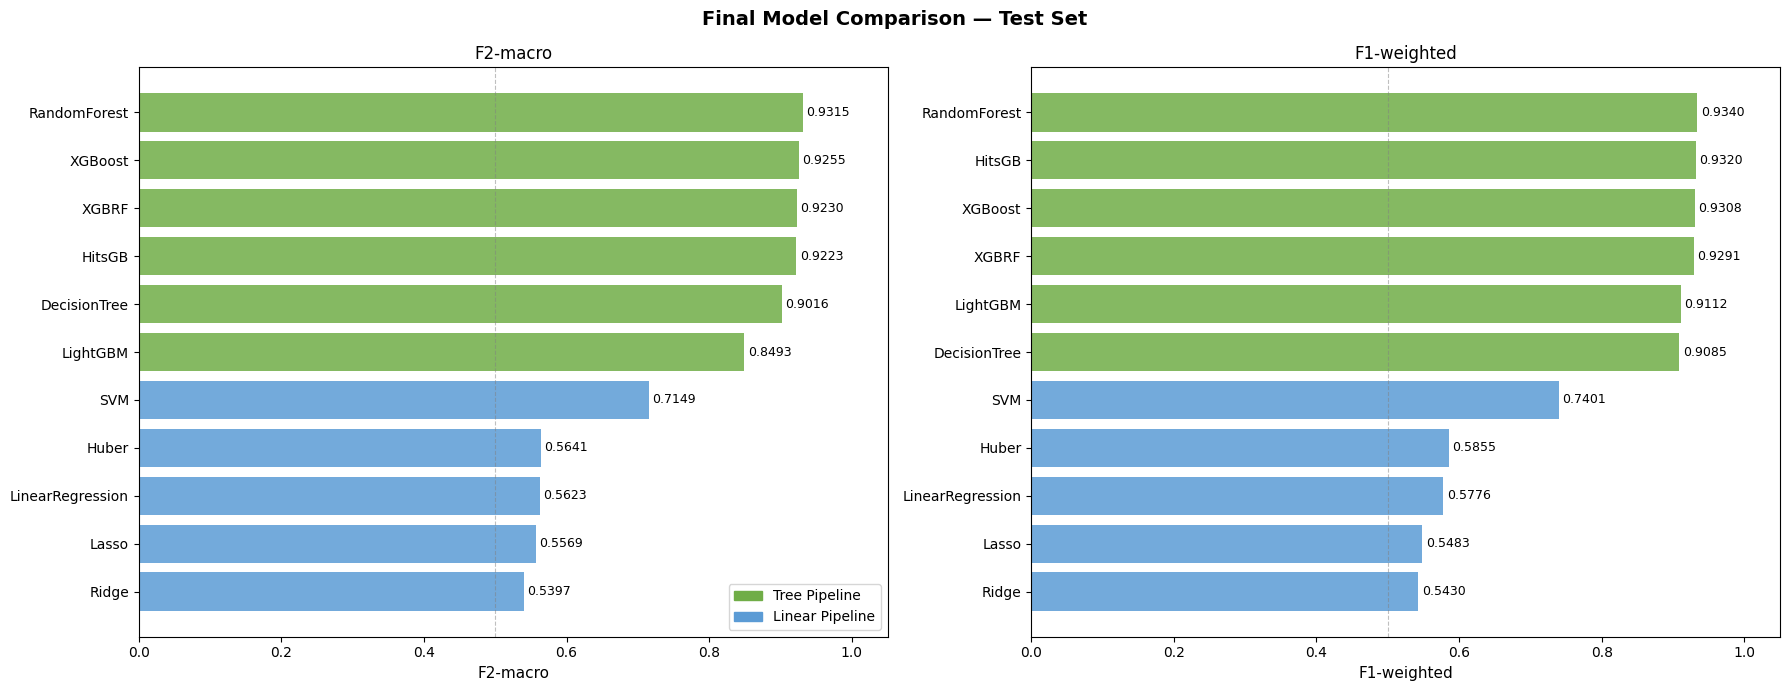

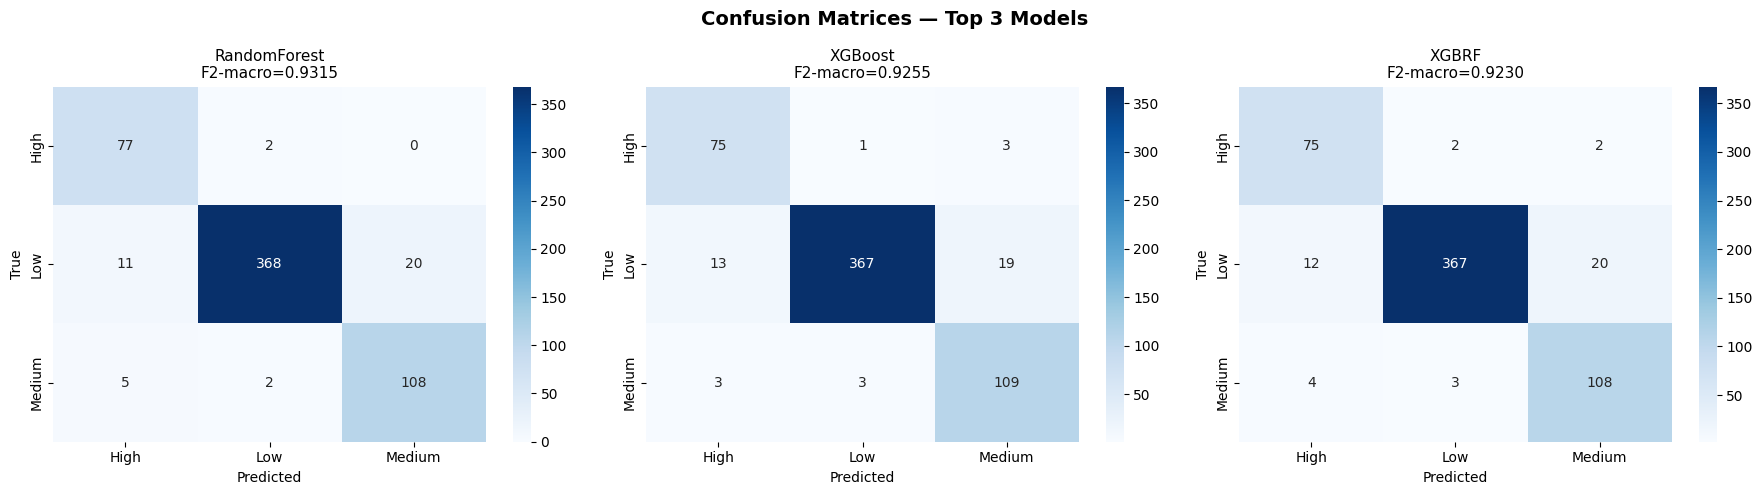

In [9]:
# ================================================================== #
# CELL 8 — Visualize: Bar Chart So Sánh
# ================================================================== #
 
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Final Model Comparison — Test Set',
             fontsize=14, fontweight='bold')
 
colors_map = {'Tree': '#70AD47', 'Linear': '#5B9BD5'}
 
for ax, metric in zip(axes, ['F2-macro', 'F1-weighted']):
    df_plot = df_results.sort_values(metric, ascending=True)
    colors  = [colors_map['Tree' if m in TREE_MODELS else 'Linear']
               for m in df_plot['Model']]
 
    bars = ax.barh(df_plot['Model'], df_plot[metric],
                   color=colors, alpha=0.85)
    ax.set_xlabel(metric, fontsize=11)
    ax.set_title(metric, fontsize=12)
    ax.set_xlim(0, 1.05)
    ax.axvline(0.5, color='gray', linestyle='--',
               linewidth=0.8, alpha=0.5)
 
    for bar, val in zip(bars, df_plot[metric]):
        ax.text(bar.get_width() + 0.005,
                bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=9)
 
from matplotlib.patches import Patch
legend = [Patch(color='#70AD47', label='Tree Pipeline'),
          Patch(color='#5B9BD5', label='Linear Pipeline')]
axes[0].legend(handles=legend, loc='lower right')
 
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'model_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()
 
 
# ================================================================== #
# CELL 9 — Confusion Matrices (Top 3 Models)
# ================================================================== #
 
top3 = df_results.head(3)['Model'].tolist()
label_names = ['High', 'Low', 'Medium']
 
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Confusion Matrices — Top 3 Models',
             fontsize=14, fontweight='bold')
 
for ax, model_name in zip(axes, top3):
    cm = np.array(detailed_metrics[model_name]['confusion_matrix'])
    sns.heatmap(
        cm, ax=ax, annot=True, fmt='d',
        cmap='Blues',
        xticklabels=label_names,
        yticklabels=label_names
    )
    f2 = detailed_metrics[model_name]['f2_macro']
    ax.set_title(f'{model_name}\nF2-macro={f2:.4f}', fontsize=11)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
 
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'confusion_matrices_top3.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# ================================================================== #
# CELL 10 — Lưu Kết Quả
# ================================================================== #
 
# CSV
df_results.to_csv(RESULTS_DIR / 'final_metrics.csv', index=False)
df_perclass.to_csv(RESULTS_DIR / 'per_class_metrics.csv', index=False)
 
# JSON chi tiết
save_data = {}
for model_name, metrics in detailed_metrics.items():
    split_metrics = all_results[model_name]
    save_data[model_name] = {
        'train_f2_macro'   : split_metrics['train_f2_macro'],
        'train_f1_weighted': split_metrics['train_f1_weighted'],
        'test_f2_macro'    : split_metrics['test_f2_macro'],
        'test_f1_weighted' : split_metrics['test_f1_weighted'],
        'best_params'     : metrics['best_params'],
        'confusion_matrix': metrics['confusion_matrix'],
        'per_class'       : {
            cls: {
                'precision': metrics['per_class'][cls]['precision'],
                'recall'   : metrics['per_class'][cls]['recall'],
                'f1-score' : metrics['per_class'][cls]['f1-score'],
                'support'  : metrics['per_class'][cls]['support'],
            }
            for cls in ['High', 'Medium', 'Low']
        }
    }
 
with open(RESULTS_DIR / 'detailed_metrics.json', 'w') as f:
    json.dump(save_data, f, indent=2)
 
print("Results saved:")
print(f"  {RESULTS_DIR / 'final_metrics.csv'}")
print(f"  {RESULTS_DIR / 'per_class_metrics.csv'}")
print(f"  {RESULTS_DIR / 'detailed_metrics.json'}")
print(f"\nModels in {MODELS_DIR}/:")
for p in sorted(MODELS_DIR.glob('*.pkl')):
    size_mb = p.stat().st_size / 1024 / 1024
    print(f"  {p.name} ({size_mb:.1f} MB)")

Results saved:
  ../flood-forecast/results/final/final_metrics.csv
  ../flood-forecast/results/final/per_class_metrics.csv
  ../flood-forecast/results/final/detailed_metrics.json

Models in ../flood-forecast/saved_models/:
  DecisionTree.pkl (0.1 MB)
  HitsGB.pkl (1.1 MB)
  Huber.pkl (0.1 MB)
  Lasso.pkl (0.1 MB)
  LightGBM.pkl (5.7 MB)
  LinearRegression.pkl (0.1 MB)
  RandomForest.pkl (16.2 MB)
  Ridge.pkl (0.1 MB)
  SVM.pkl (1.8 MB)
  XGBRF.pkl (4.7 MB)
  XGBoost.pkl (1.6 MB)


In [11]:
# ================================================================== #
# CELL 11 — Best Model Summary
# ================================================================== #
 
best_name    = df_results.iloc[0]['Model']
best_metrics = detailed_metrics[best_name]
 
print(f"\n{'='*55}")
print(f"BEST MODEL: {best_name}")
print(f"{'='*55}")
best_splits = all_results[best_name]
print(f"  Train F2/F1: {best_splits['train_f2_macro']:.4f} / "
      f"{best_splits['train_f1_weighted']:.4f}")
print(f"  Test  F2/F1: {best_splits['test_f2_macro']:.4f} / "
      f"{best_splits['test_f1_weighted']:.4f}")
 
if best_metrics['best_params']:
    print(f"  Best params : {best_metrics['best_params']}")
 
print(f"\nPer-class performance:")
print(f"  {'Class':8s} {'Precision':>10} {'Recall':>8} "
      f"{'F1':>8} {'Support':>8}")
print(f"  {'-'*46}")
for cls in ['High', 'Medium', 'Low']:
    pc = best_metrics['per_class'][cls]
    print(f"  {cls:8s} {pc['precision']:>10.3f} {pc['recall']:>8.3f} "
          f"{pc['f1-score']:>8.3f} {pc['support']:>8.0f}")
 
print(f"\n{'='*55}")
print(f"FULL RANKING:")
print(f"{'='*55}")
print(df_results[['Rank', 'Model', 'Pipeline',
                  'Train F2-macro', 'Train F1-weighted',
                  'Test F2-macro', 'Test F1-weighted',
                  'F2 gap', 'F1 gap']]
      .to_string(index=False))
 


BEST MODEL: RandomForest
  F2-macro    : 0.9315
  F1-weighted : 0.9340

Per-class performance:
  Class     Precision   Recall       F1  Support
  ----------------------------------------------
  High          0.828    0.975    0.895       79
  Medium        0.844    0.939    0.889      115
  Low           0.989    0.922    0.955      399

FULL RANKING:
 Rank            Model Pipeline  F2-macro  F1-weighted
    1     RandomForest     Tree    0.9315       0.9340
    2          XGBoost     Tree    0.9255       0.9308
    3            XGBRF     Tree    0.9230       0.9291
    4           HitsGB     Tree    0.9223       0.9320
    5     DecisionTree     Tree    0.9016       0.9085
    6         LightGBM     Tree    0.8493       0.9112
    7              SVM   Linear    0.7149       0.7401
    8            Huber   Linear    0.5641       0.5855
    9 LinearRegression   Linear    0.5623       0.5776
   10            Lasso   Linear    0.5569       0.5483
   11            Ridge   Linear    0.53